## Tutorial for Applying SoccerCPD to kloppy Data

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import rpy2.robjects as robjects
import rpy2.robjects.packages as rpackages

from src.match import Match
from src.kloppy import Kloppy
from src.soccercpd import SoccerCPD

In [2]:
# robjects.r(".libPaths('/usr/lib/R/site-library')")
utils = rpackages.importr('utils')
utils.chooseCRANmirror(ind=1)
if not rpackages.isinstalled('gSeg'):
    utils.install_packages('gSeg')
rpackages.importr('gSeg')

rpy2.robjects.packages.Package as a <module 'gSeg'>

### Converting preprocessed RGP data into SoccerCPD format

In [3]:
matches = pd.read_csv("data/matches.csv", index_col=0, header=0, encoding="utf-8-sig")

In [37]:
match_index = 16
home_away = "away"  # Choose either home or away
home_id = matches.at[match_index, "home_id"]
away_id = matches.at[match_index, "away_id"]
col_dict = {"index": "frame_id", "session": "period_id", "time": "timestamp"}

if away_id == 0:
    home_away = "home"
    col_dict["phase"] = "home_phase"
    data = pd.read_csv(f"data/kloppy/{home_id}.csv", header=0, parse_dates=["datetime"])
elif home_id == 0:
    home_away = "away"
    col_dict["phase"] = "away_phase"
    data = pd.read_csv(f"data/kloppy/{away_id}.csv", header=0, parse_dates=["datetime"])
else:
    data = pd.read_csv(f"data/kloppy/{home_id}-{away_id}.csv", header=0, parse_dates=["datetime"])
    
data = data.reset_index().rename(columns=col_dict)
data

,frame_id,datetime,period_id,timestamp,away_phase,away_03_x,away_03_y,away_03_speed,away_05_x,away_05_y,...,away_27_speed,away_29_x,away_29_y,away_29_speed,away_32_x,away_32_y,away_32_speed,away_37_x,away_37_y,away_37_speed
0,0,2024-10-25 05:00:08.000,1,0.0,1,17.718820,6.324433,1.684,18.070886,-5.508991,...,0.224,-0.626186,-13.759790,0.194,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2024-10-25 05:00:08.100,1,0.1,1,17.702732,6.267166,2.017,18.088567,-5.522849,...,0.156,-0.626186,-13.759790,0.276,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2024-10-25 05:00:08.200,1,0.2,1,17.703370,6.238716,1.672,18.089205,-5.551299,...,0.144,-0.625867,-13.774015,0.130,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2024-10-25 05:00:08.300,1,0.3,1,17.704326,6.196041,1.727,18.106567,-5.550933,...,0.356,-0.608505,-13.773649,0.276,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2024-10-25 05:00:08.400,1,0.4,1,17.687602,6.167224,1.040,18.089205,-5.551299,...,0.668,-0.608186,-13.787874,0.307,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44165,44165,2024-10-25 06:24:49.500,2,2166.5,4,-27.636709,-2.176301,6.957,-24.970637,4.426603,...,3.085,NaN,NaN,NaN,NaN,NaN,NaN,-21.495578,-5.689930,4.400
44166,44166,2024-10-25 06:24:49.600,2,2166.6,4,-27.745666,-1.965126,9.566,-25.041044,4.467812,...,2.885,NaN,NaN,NaN,NaN,NaN,NaN,-21.567259,-5.591821,4.709
44167,44167,2024-10-25 06:24:49.700,2,2166.7,4,-27.819579,-1.767442,7.559,-25.093769,4.495162,...,3.753,NaN,NaN,NaN,NaN,NaN,NaN,-21.621578,-5.493346,4.757
44168,44168,2024-10-25 06:24:49.800,2,2166.8,4,-27.875174,-1.612068,6.071,-25.129132,4.522878,...,3.828,NaN,NaN,NaN,NaN,NaN,NaN,-21.692941,-5.409463,4.170


In [42]:
kloppy = Kloppy(data)
kloppy.rotate_pitch([1])
input_data = kloppy.convert_to_soccercpd_input(exclude_gks=False)
input_data

,datetime,team,player_id,player_period,session,time,x,y,speed
0,2024-10-25 05:00:08.000,away,3,1,1,0.0,-17.718820,-6.324433,1.684
1,2024-10-25 05:00:08.100,away,3,1,1,0.1,-17.702732,-6.267166,2.017
2,2024-10-25 05:00:08.200,away,3,1,1,0.2,-17.703370,-6.238716,1.672
3,2024-10-25 05:00:08.300,away,3,1,1,0.3,-17.704326,-6.196041,1.727
4,2024-10-25 05:00:08.400,away,3,1,1,0.4,-17.687602,-6.167224,1.040
...,...,...,...,...,...,...,...,...,...
44165,2024-10-25 06:24:49.500,away,37,4,2,2166.5,-21.495578,-5.689930,4.400
44166,2024-10-25 06:24:49.600,away,37,4,2,2166.6,-21.567259,-5.591821,4.709
44167,2024-10-25 06:24:49.700,away,37,4,2,2166.7,-21.621578,-5.493346,4.757
44168,2024-10-25 06:24:49.800,away,37,4,2,2166.8,-21.692941,-5.409463,4.170


### Converting kloppy data into SoccerCPD format

In [ ]:
data = pd.read_pickle("data/kloppy/sample_kloppy_file.pkl")
data

In [ ]:
kloppy = Kloppy(data)
kloppy.preprocess_times()
kloppy.round_change_times()
kloppy.label_player_periods()
input_data = kloppy.convert_to_soccercpd_input()
input_data

### Formation detection per team

In [43]:
# home_away = "away"  # Choose either home or away
team_data = input_data[input_data["team"] == home_away]
cpd = SoccerCPD(team_data)
# cpd = SoccerCPD(team_data, formcpd_method=None)
cpd.run()


------------------------ Subsession 1 ------------------------
               session            start_dt              end_dt
player_period                                                 
1                    1 2024-10-25 05:00:08 2024-10-25 05:34:43
2                    1 2024-10-25 05:34:43 2024-10-25 05:37:38

* Step 1: Frame-by-frame role assignment using RoleRep
- Cost after iteration 1: 6.137
- Cost after iteration 2: 6.076
- Cost after iteration 3: 6.073
Iteration finished since there are no significant changes.

* Step 2: FormCPD based on role-adjacency matrices
Applying g-segmentation to the sequence between 05:00:08 and 05:37:37...
Generalized edge-count statistic (a) : 
  Estimated change-point location: 224 
  Test statistic: 1833.193 
  Approximated p-value: 0 
Generalized edge-count statistic (u) : 
  Estimated change-point location: 1109 
  Test statistic: 3693.537 
  Approximated p-value: 0 
Change-point insignificant: One of the periods has not enough duration.

Dete

### Label assignment using precomputed formation clusters

In [44]:
benchmark_forms = pd.read_pickle("data/benchmark_forms.pkl")
benchmark_roles = pd.read_csv("data/benchmark_roles.csv", header=0)
cpd.label_roles(benchmark_roles, benchmark_forms)

# form_labels = {1: "442", 2: "442"}
# cpd.label_roles(benchmark_roles, form_labels=form_labels)
cpd.role_labels

,1,2,3,4,5,6,7,8,9,10
1,RCB,LCB,LB,RM,RB,CDM,LCM,LM,RCM,CF
2,RCB,LCB,LB,RM,RB,CDM,LCM,LM,RCM,CF


### Saving results and visualization

In [45]:
activity_id = home_id if home_away == "home" else away_id
roster = pd.read_csv(f"data/roster/{activity_id}.csv", index_col=0, header=0)
# cpd.save_results(match_id=activity_id)
cpd.visualize(roster, role_labels=cpd.role_labels, save_dir=f"results/{activity_id}")

Successfully saved in 'results/83046/timeline.png'.


### Calculating and visualizing stats per player-role pair

Successfully saved in 'results/83120/stats.csv'.
Successfully saved in 'results/83120/plot_dist.png'.


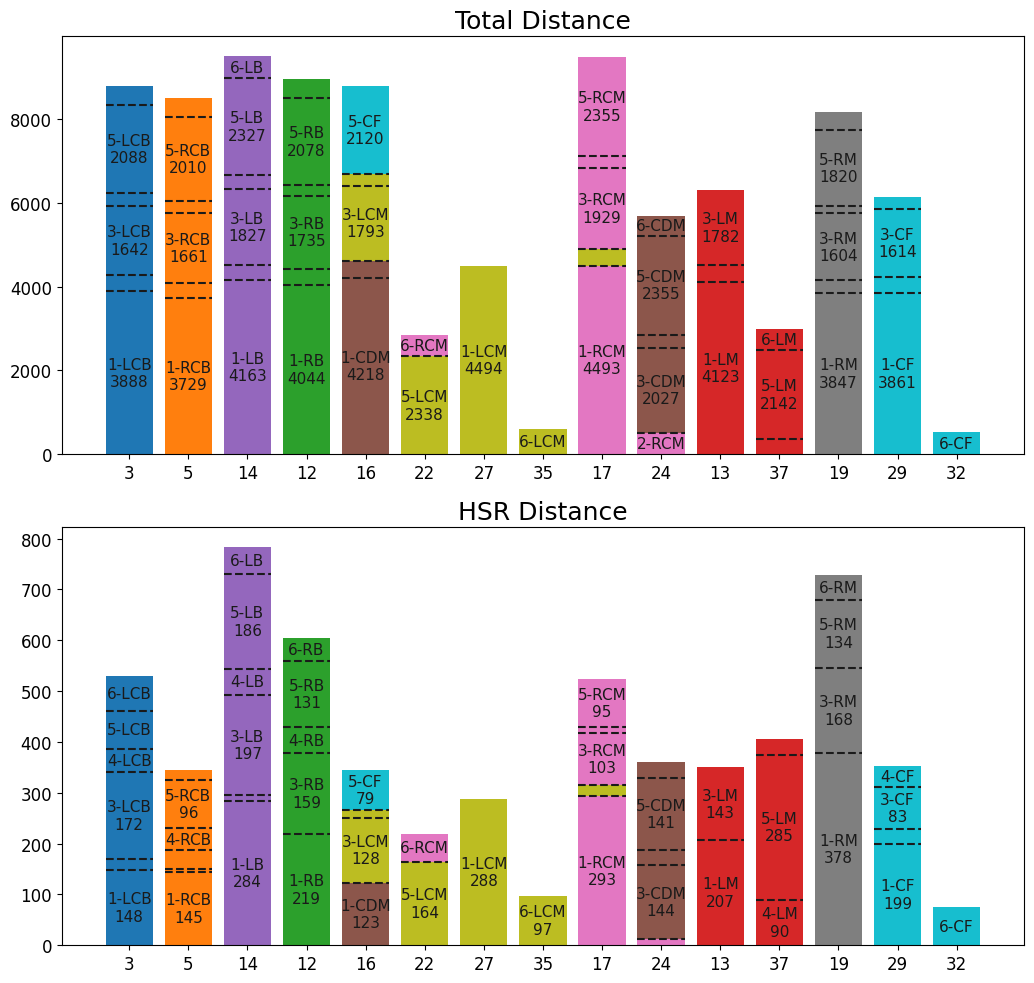

In [35]:
match = Match(cpd.data, cpd.role_summary, id=activity_id)
match.compute_stats(save=True)
match.plot_by_player(save=True)

Successfully saved in 'results/83120/plot_dist_90min.png'.


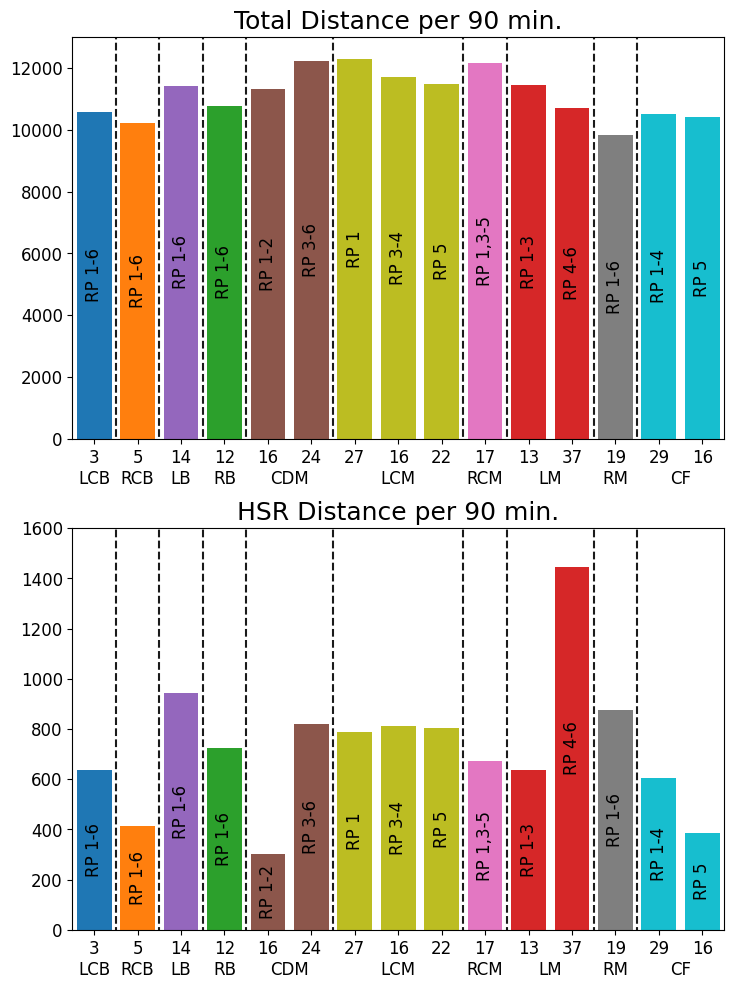

In [36]:
match.compute_role_stats()
match.plot_by_role(save=True)

### Aggregating statistics resulting from multiple matches